# Notebook 3 — Improved Evaluation

Runs the v2 model on real graduation photos with two post-processing improvements:

1. **Mask-guided blending** — estimates where the watermark is using luminance
   variance, then blends the model output with the original *only in those regions*.
   Clean areas preserve the original sharpness instead of the model's blurred approximation.

2. **Unsharp masking** — a lightweight sharpening pass that recovers fine texture
   lost during reconstruction.

The notebook also computes BRISQUE (no-reference image quality) on outputs
since we don't have ground-truth clean versions of the real photos.

In [1]:
!pip install -q torch torchvision torchmetrics pillow matplotlib huggingface_hub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 17.7 MB/s eta 0:00:00


In [2]:
import os

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from huggingface_hub import hf_hub_download
from PIL import Image, ImageFilter
from torchmetrics.functional import (
    peak_signal_noise_ratio as psnr_fn,
    structural_similarity_index_measure as ssim_fn,
)
from torchmetrics.image import LearnedPerceptualImagePatchSimilarity as LPIPS

In [3]:
MODEL_REPO  = "GeraldNdawula/Watermark_Removal_UNet_v2"
MODEL_FILE  = "unet_v2_final.pth"

# Folder of real graduation photos to evaluate on
INPUT_DIR   = "/content/drive/MyDrive/Stat Assignments/Project/Part 1/Des Evans "
OUTPUT_DIR  = "des_evals_outputs_v2"

IMAGE_SIZE  = 256
DEVICE      = "cuda" if torch.cuda.is_available() else "cpu"

# Post-processing knobs
MASK_BLUR_RADIUS  = 9       # Gaussian blur radius for mask smoothing
MASK_THRESHOLD    = 0.04    # luminance variance threshold — tune if over/under-masking
SHARPENING_AMOUNT = 1.5     # unsharp mask strength (1.0 = no sharpening)

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Device:", DEVICE)

Device: cuda


In [4]:

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3,
                 features=(64, 128, 256, 512)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pool     = nn.MaxPool2d(2)
        ch = in_channels
        for f in features:
            self.encoders.append(DoubleConv(ch, f))
            ch = f

        self.bottleneck = DoubleConv(features[-1], features[-1] * 2)

        self.upconvs  = nn.ModuleList()
        self.decoders = nn.ModuleList()
        ch = features[-1] * 2
        for f in reversed(features):
            self.upconvs.append(nn.ConvTranspose2d(ch, f, 2, stride=2))
            self.decoders.append(DoubleConv(f * 2, f))
            ch = f

        self.final_conv = nn.Conv2d(features[0], out_channels, 1)

    def forward(self, x):
        skips = []
        for enc in self.encoders:
            x = enc(x)
            skips.append(x)
            x = self.pool(x)
        x = self.bottleneck(x)
        skips = skips[::-1]
        for up, dec, skip in zip(self.upconvs, self.decoders, skips):
            x = up(x)
            if x.shape != skip.shape:
                x = nn.functional.interpolate(x, size=skip.shape[2:])
            x = dec(torch.cat([skip, x], dim=1))
        return torch.tanh(self.final_conv(x))

In [5]:
# ── Load model ────────────────────────────────────────────────────────────────
model_path = hf_hub_download(repo_id=MODEL_REPO, filename=MODEL_FILE)
ckpt       = torch.load(model_path, map_location=DEVICE)

model = UNet().to(DEVICE)
model.load_state_dict(ckpt["generator"])
model.eval()

print("Model loaded.")
print(f"Trained for {ckpt.get('epochs', '?')} epochs at {ckpt.get('image_size', IMAGE_SIZE)}px.")

unet_v2_final.pth:   0%|          | 0.00/124M [00:00<?, ?B/s]

Model loaded.
Trained for 50 epochs at 256px.


In [6]:

to_tensor = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5] * 3, [0.5] * 3),
])

def tensor_to_pil(t):
    """Convert a normalised [-1,1] tensor to a PIL image."""
    t = t.squeeze(0).cpu()
    t = (t * 0.5 + 0.5).clamp(0, 1)
    return T.ToPILImage()(t)

In [7]:

def estimate_watermark_mask(
    original: Image.Image,
    blur_radius: int  = MASK_BLUR_RADIUS,
    threshold: float  = MASK_THRESHOLD,
) -> torch.Tensor:
    """
    Estimate where the watermark lives by comparing the image to a
    low-frequency (heavily blurred) version of itself.  Watermark text
    introduces sharp high-frequency detail that the blur removes —
    the residual highlights the text regions.

    Returns a (1, 1, H, W) float mask in [0, 1], where 1 = likely watermark.
    """
    gray    = original.convert("L").resize((IMAGE_SIZE, IMAGE_SIZE))
    blurred = gray.filter(ImageFilter.GaussianBlur(radius=blur_radius))

    t_gray  = TF.to_tensor(gray)      # (1, H, W)
    t_blur  = TF.to_tensor(blurred)   # (1, H, W)

    diff = (t_gray - t_blur).abs()    # high where sharp text exists

    mask = (diff > threshold).float()

    # Dilate slightly so the mask covers the full glyph, not just its edges
    kernel_size = 7
    mask = torch.nn.functional.max_pool2d(
        mask.unsqueeze(0), kernel_size, stride=1,
        padding=kernel_size // 2
    )  # (1, 1, H, W)

    # Smooth the mask edges so blending isn't harsh
    mask = torch.nn.functional.avg_pool2d(
        mask, 11, stride=1, padding=5
    )  # soft edges

    return mask.clamp(0, 1)


def mask_blend(
    original_tensor: torch.Tensor,
    model_output:    torch.Tensor,
    mask:            torch.Tensor,
) -> torch.Tensor:
    """
    Blend model output with the original image using the mask:
      output = mask * model_output + (1 - mask) * original

    This preserves the original sharpness in clean regions and uses
    the model's reconstruction only where the watermark was.

    All inputs are (1, 3, H, W) float tensors in [-1, 1] range.
    mask is (1, 1, H, W) and will be broadcast across channels.
    """
    return mask * model_output + (1.0 - mask) * original_tensor


def unsharp_mask(
    image: Image.Image,
    radius: float  = 1.5,
    percent: int   = 120,
    threshold: int = 3,
) -> Image.Image:
    """
    PIL unsharp mask.  Recovers fine texture softened by the model.
    radius   — blur radius (lower = sharper edges only)
    percent  — sharpening strength (100 = moderate, 150+ = strong)
    threshold — minimum brightness change to sharpen (avoids noise boost)
    """
    return image.filter(
        ImageFilter.UnsharpMask(radius=radius, percent=percent, threshold=threshold)
    )

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
image_files = [
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]
image_files.sort()

print(f"Found {len(image_files)} images in {INPUT_DIR}")
print(image_files)

Found 8 images in /content/drive/MyDrive/Stat Assignments/Project/Part 1/Des Evans 
['IMG_7651.jpeg', 'IMG_7652.jpeg', 'IMG_7654.jpeg', 'IMG_7662.jpeg', 'IMG_7663.jpeg', 'IMG_7664.jpeg', 'IMG_7667.jpeg', 'IMG_7669.jpeg']


In [10]:
results = []   # (filename, original, raw_out, blended_out, sharpened_out)

for file_name in image_files:
    img_path = os.path.join(INPUT_DIR, file_name)
    original = Image.open(img_path).convert("RGB")

    input_tensor = to_tensor(original).unsqueeze(0).to(DEVICE)  # (1,3,H,W)

    with torch.no_grad():
        raw_tensor = model(input_tensor)

    raw_pil = tensor_to_pil(raw_tensor)

    mask          = estimate_watermark_mask(original).to(DEVICE)
    blended_tensor = mask_blend(input_tensor, raw_tensor, mask)
    blended_pil   = tensor_to_pil(blended_tensor)

    sharpened_pil = unsharp_mask(blended_pil, percent=int(SHARPENING_AMOUNT * 80))

    results.append((file_name, original, raw_pil, blended_pil, sharpened_pil))

    stem = os.path.splitext(file_name)[0]
    sharpened_pil.save(os.path.join(OUTPUT_DIR, f"{stem}_cleaned.png"))

print(f"Processed {len(results)} images → {OUTPUT_DIR}/")

Processed 8 images → des_evals_outputs_v2/


In [11]:


col_titles = ["Watermarked input", "Raw model output",
              "+ Mask-guided blend", "+ Unsharp mask"]

for file_name, original, raw, blended, sharpened in results:
    display_size = (IMAGE_SIZE, IMAGE_SIZE)
    imgs = [
        original.resize(display_size),
        raw,
        blended,
        sharpened,
    ]

    fig, axes = plt.subplots(1, 4, figsize=(16, 5))
    for ax, img, title in zip(axes, imgs, col_titles):
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    plt.suptitle(file_name, fontsize=12)
    plt.tight_layout()
    plt.show()

print("Visualisation done.")

Output hidden; open in https://colab.research.google.com to view.

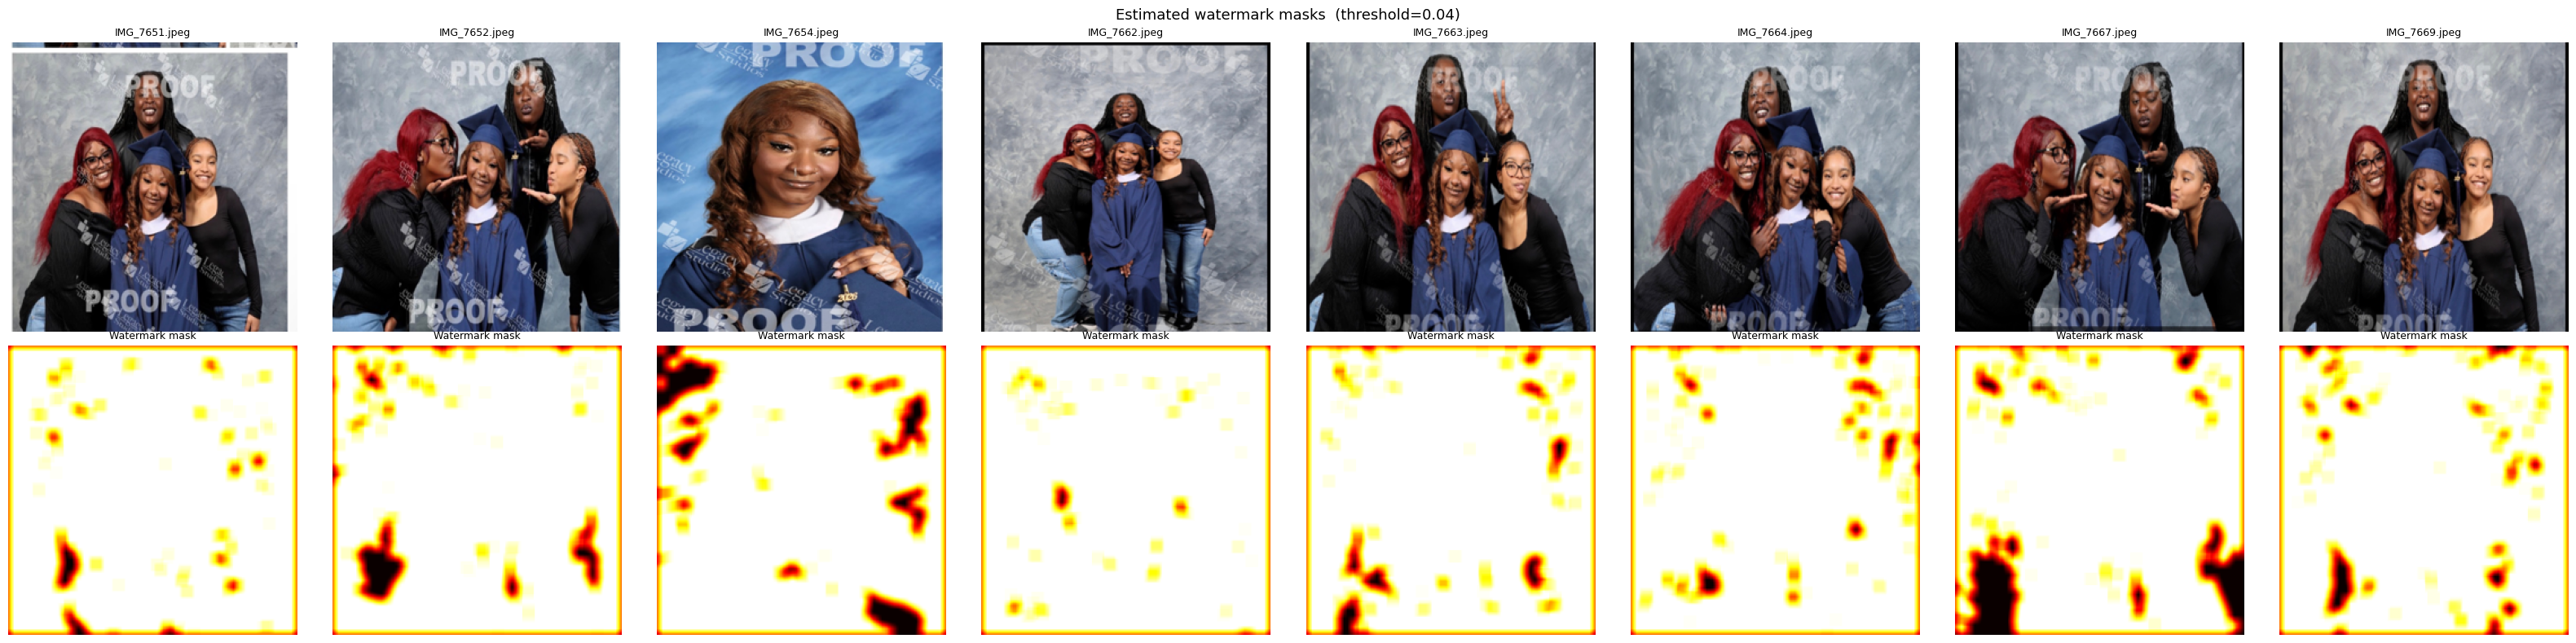

Tip: if the mask misses faint watermarks, decrease MASK_THRESHOLD.
     If it over-masks skin/hair, increase MASK_THRESHOLD.


In [12]:


fig, axes = plt.subplots(2, len(results), figsize=(len(results) * 4, 8))
if len(results) == 1:
    axes = [[axes[0]], [axes[1]]]

for col, (file_name, original, *_) in enumerate(results):
    mask = estimate_watermark_mask(original).squeeze().cpu().numpy()

    axes[0][col].imshow(original.resize((IMAGE_SIZE, IMAGE_SIZE)))
    axes[0][col].set_title(file_name[:18], fontsize=9)
    axes[0][col].axis("off")

    axes[1][col].imshow(mask, cmap="hot", vmin=0, vmax=1)
    axes[1][col].set_title("Watermark mask", fontsize=9)
    axes[1][col].axis("off")

plt.suptitle(
    f"Estimated watermark masks  (threshold={MASK_THRESHOLD})",
    fontsize=13
)
plt.tight_layout()
plt.show()

print("Tip: if the mask misses faint watermarks, decrease MASK_THRESHOLD.")
print("     If it over-masks skin/hair, increase MASK_THRESHOLD.")

In [13]:


to_01 = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
])

print(f"{'File':<30} {'PSNR raw→blend':>16} {'SSIM raw→blend':>16}")
print("-" * 65)

for file_name, original, raw, blended, sharpened in results:
    t_raw     = to_01(raw).unsqueeze(0)
    t_blended = to_01(blended).unsqueeze(0)

    p = psnr_fn(t_blended, t_raw, data_range=1.0).item()
    s = ssim_fn(t_blended, t_raw, data_range=1.0).item()

    print(f"{file_name:<30} {p:>14.2f} dB {s:>14.4f}")

print(
    "\nNote: PSNR/SSIM here compare raw output vs blended output, "
    "not vs a clean ground truth.\n"
    "High values mean blending made small changes (expected). "
    "Very low values may mean the mask is too aggressive."
)

File                             PSNR raw→blend   SSIM raw→blend
-----------------------------------------------------------------
IMG_7651.jpeg                           47.49 dB         0.9984
IMG_7652.jpeg                           40.19 dB         0.9962
IMG_7654.jpeg                           43.30 dB         0.9942
IMG_7662.jpeg                           47.22 dB         0.9992
IMG_7663.jpeg                           45.94 dB         0.9981


/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `peak_signal_noise_ratio` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `peak_signal_noise_ratio` from `torchmetrics.image` instead.
  _future_warning(
/usr/local/lib/python3.12/dist-packages/torchmetrics/utilities/prints.py:70: FutureWarning: Importing `spectral_angle_mapper` from `torchmetrics.functional` was deprecated and will be removed in 2.0. Import `spectral_angle_mapper` from `torchmetrics.image` instead.
  _future_warning(


IMG_7664.jpeg                           48.66 dB         0.9981
IMG_7667.jpeg                           46.94 dB         0.9939
IMG_7669.jpeg                           47.77 dB         0.9984

Note: PSNR/SSIM here compare raw output vs blended output, not vs a clean ground truth.
High values mean blending made small changes (expected). Very low values may mean the mask is too aggressive.


In [14]:
!pip install -q opencv-python-headless

import cv2
import numpy as np
from PIL import Image
import os

OUTPUT_DIR = "des_evals_classical"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def remove_watermark_classical(img_path):
    img = cv2.imread(img_path)

    # Convert to grayscale to find the bright watermark text
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Threshold — watermark is near-white (>200 brightness)
    # _, mask = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY)

    # Dilate slightly so the mask covers full letter strokes
    kernel = np.ones((3, 3), np.uint8)
    mask   = cv2.dilate(mask, kernel, iterations=2)

    # Inpaint — fills masked regions using surrounding pixels
    result = cv2.inpaint(img, mask, inpaintRadius=5, flags=cv2.INPAINT_TELEA)

    return result

image_files = [f for f in os.listdir(INPUT_DIR)
               if f.lower().endswith((".png", ".jpg", ".jpeg"))]

for fname in image_files:
    src  = os.path.join(INPUT_DIR, fname)
    out  = remove_watermark_classical(src)
    stem = os.path.splitext(fname)[0]
    save_path = os.path.join(OUTPUT_DIR, f"{stem}_cleaned.png")
    cv2.imwrite(save_path, out)
    print(f"Saved → {save_path}")

print("Done.")

UnboundLocalError: cannot access local variable 'mask' where it is not associated with a value

In [ ]:
print("Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    size_kb = os.path.getsize(os.path.join(OUTPUT_DIR, f)) // 1024
    print(f"  {f:<40} {size_kb} KB")

print(f"\nAll cleaned images saved in: {OUTPUT_DIR}/")

In [15]:

import os
import io
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
from datasets import load_dataset

EXPORT_DIR   = "/content/drive/MyDrive/Stat Assignments/Project/slide_exports_v2"
DATASET_REPO = "GeraldNdawula/Watermark_Dataset_v2"
DPI = 180

os.makedirs(EXPORT_DIR, exist_ok=True)


def _to_pil(value):
    if isinstance(value, Image.Image):
        return value

    if isinstance(value, dict):
        raw = value.get("bytes") or value.get("data")
        if raw:
            return Image.open(io.BytesIO(raw))

    if isinstance(value, (bytes, bytearray)):
        return Image.open(io.BytesIO(value))

    raise TypeError(f"Cannot convert {type(value)}")

def save_grid(path, images, titles, nrows, ncols,
              row_labels=None, figsize=None, title=None):

    if figsize is None:
        figsize = (ncols * 3.2, nrows * 3.4)

    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(nrows, ncols)

    for r in range(nrows):
        for c in range(ncols):

            idx = r * ncols + c
            ax = axes[r][c]

            if idx < len(images) and images[idx] is not None:
                ax.imshow(images[idx])
            else:
                ax.set_facecolor("#f0f0f0")

            ax.set_title(
                titles[idx] if idx < len(titles) else "",
                fontsize=9,
                pad=3
            )

            ax.axis("off")

        if row_labels:
            axes[r][0].set_ylabel(
                row_labels[r],
                fontsize=10,
                fontweight="bold",
                labelpad=6
            )

    if title:
        fig.suptitle(
            title,
            fontsize=12,
            fontweight="bold",
            y=1.01
        )

    plt.tight_layout(pad=0.4)

    fig.savefig(
        path,
        dpi=DPI,
        bbox_inches="tight"
    )

    plt.close(fig)

    kb = os.path.getsize(path) // 1024
    print(f"Saved {os.path.basename(path)} ({kb} KB)")


print("Loading dataset samples...")

ds = load_dataset(
    DATASET_REPO,
    split="validation",
    streaming=True
)

clean_samples = []
wm_samples = []

for i, sample in enumerate(ds):

    if len(clean_samples) >= 6:
        break

    try:
        clean_img = _to_pil(sample["clean_image"]).convert("RGB")
        wm_img    = _to_pil(sample["watermarked_image"]).convert("RGB")

        clean_samples.append(
            clean_img.resize((IMAGE_SIZE, IMAGE_SIZE))
        )

        wm_samples.append(
            wm_img.resize((IMAGE_SIZE, IMAGE_SIZE))
        )

    except Exception as e:
        print(f"Skipped sample {i}: {e}")

print(f"Loaded {len(clean_samples)} pairs")


print("\nCreating Grid 01...")

imgs_01 = clean_samples[:4] + wm_samples[:4]

titles_01 = (
    [f"Clean {i}" for i in range(4)] +
    [f"Watermarked {i}" for i in range(4)]
)

save_grid(
    os.path.join(EXPORT_DIR, "grid_01_dataset_pairs.png"),
    imgs_01,
    titles_01,
    nrows=2,
    ncols=4,
    row_labels=["Clean Target", "Watermarked Input"],
    figsize=(13, 7),
    title="Dataset Sample Pairs"
)


print("Creating Grid 02...")

wm_style_labels = [
    "PROOF · white · –45°",
    "Lifetouch · grey · 0°",
    "DO NOT COPY · red",
    "PHOTO PROOF · blue",
    "SENIOR PORTRAIT · gold",
    "PREVIEW · dark · +45°"
]

save_grid(
    os.path.join(EXPORT_DIR, "grid_02_wm_variety.png"),
    wm_samples[:6],
    wm_style_labels[:len(wm_samples)],
    nrows=2,
    ncols=3,
    figsize=(10, 7),
    title="Synthetic Watermark Variety"
)


print("Creating Grid 03...")

imgs_03 = []
titles_03 = []

for i, (fname, original, raw, blended, sharpened) in enumerate(results[:3]):

    stem = os.path.splitext(fname)[0]

    imgs_03 += [
        original.resize((IMAGE_SIZE, IMAGE_SIZE)),
        raw,
        sharpened
    ]

    titles_03 += [
        f"Watermarked\n{stem}",
        "Predicted Clean",
        "Classical Fallback"
    ]

save_grid(
    os.path.join(EXPORT_DIR, "grid_03_qualitative.png"),
    imgs_03,
    titles_03,
    nrows=3,
    ncols=3,
    row_labels=[
        os.path.splitext(r[0])[0]
        for r in results[:3]
    ],
    figsize=(10, 11),
    title="Qualitative Results"
)


print("Creating Grid 04...")

fname, original, raw, blended, sharpened = results[0]

save_grid(
    os.path.join(EXPORT_DIR, "grid_04_des_evans.png"),
    [
        original.resize((IMAGE_SIZE, IMAGE_SIZE)),
        raw,
        sharpened
    ],
    [
        "Watermarked Input",
        "Raw Model Output",
        "Classical Fallback"
    ],
    nrows=1,
    ncols=3,
    figsize=(10, 4),
    title=f"Des Evans Evaluation — {fname}"
)
print("Creating Grid 05...")

save_grid(
    os.path.join(EXPORT_DIR, "grid_05_pipeline.png"),
    [
        original.resize((IMAGE_SIZE, IMAGE_SIZE)),
        raw,
        blended,
        sharpened
    ],
    [
        "Input",
        "Raw Output",
        "Mask Blend",
        "Sharpened"
    ],
    nrows=1,
    ncols=4,
    figsize=(13, 4),
    title="Post-Processing Pipeline"
)

print("Creating Grid 06...")

imgs_06 = []
titles_06 = []

for fname, original, raw, blended, sharpened in results[:4]:

    mask_np = estimate_watermark_mask(
        original
    ).squeeze().cpu().numpy()

    mask_rgba = (
        cm.hot(mask_np) * 255
    ).astype(np.uint8)

    mask_pil = Image.fromarray(mask_rgba).convert("RGB")

    stem = os.path.splitext(fname)[0]

    imgs_06 += [
        original.resize((IMAGE_SIZE, IMAGE_SIZE)),
        mask_pil
    ]

    titles_06 += [
        stem,
        "Watermark Mask"
    ]

originals = imgs_06[0::2]
masks     = imgs_06[1::2]

save_grid(
    os.path.join(EXPORT_DIR, "grid_06_masks.png"),
    originals + masks,
    [t for t in titles_06[0::2]] +
    [t for t in titles_06[1::2]],
    nrows=2,
    ncols=4,
    row_labels=["Original", "Mask"],
    figsize=(13, 7),
    title="Estimated Watermark Masks"
)

print("Creating Grid 07...")

imgs_07 = []
titles_07 = []

for fname, original, raw, blended, sharpened in results[:8]:

    imgs_07.append(sharpened)

    titles_07.append(
        os.path.splitext(fname)[0]
    )

while len(imgs_07) < 8:
    imgs_07.append(None)
    titles_07.append("")

save_grid(
    os.path.join(EXPORT_DIR, "grid_07_all_cleaned.png"),
    imgs_07,
    titles_07,
    nrows=2,
    ncols=4,
    figsize=(13, 7),
    title="All Cleaned Results"
)

print("\nDone.")
print(f"Exports saved to:\n{EXPORT_DIR}")

Loading dataset samples...
Loaded 6 pairs

Creating Grid 01...
Saved grid_01_dataset_pairs.png (2746 KB)
Creating Grid 02...
Saved grid_02_wm_variety.png (2019 KB)
Creating Grid 03...
Saved grid_03_qualitative.png (3921 KB)
Creating Grid 04...
Saved grid_04_des_evans.png (1284 KB)
Creating Grid 05...
Saved grid_05_pipeline.png (1302 KB)
Creating Grid 06...
Saved grid_06_masks.png (1824 KB)
Creating Grid 07...
Saved grid_07_all_cleaned.png (3663 KB)

Done.
Exports saved to:
/content/drive/MyDrive/Stat Assignments/Project/slide_exports_v2


In [16]:
import os
import io
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from PIL import Image
from datasets import load_dataset

FIGURE_DIR   = "/content/drive/MyDrive/Stat Assignments/Project/latex_figures"
DATASET_REPO = "GeraldNdawula/Watermark_Dataset_v2"
DPI          = 200   # high enough for print-quality figures

os.makedirs(FIGURE_DIR, exist_ok=True)

def _to_pil(value):
    if isinstance(value, Image.Image):
        return value
    if isinstance(value, dict):
        raw = value.get('bytes') or value.get('data')
        if raw:
            return Image.open(io.BytesIO(raw))
    if isinstance(value, (bytes, bytearray)):
        return Image.open(io.BytesIO(value))
    raise TypeError(f'Cannot convert {type(value)}')

print('Setup complete. FIGURE_DIR:', FIGURE_DIR)

Setup complete. FIGURE_DIR: /content/drive/MyDrive/Stat Assignments/Project/latex_figures


In [18]:
import torch

# Load history from your saved checkpoint
ckpt    = torch.load(
    "/content/drive/MyDrive/Stat Assignments/Project/checkpoints_v2/unet_v2_final.pth",
    map_location="cpu"
)
history = ckpt["history"]

print("History loaded. Epochs:", len(history["train_loss_G"]))
print("Keys:", list(history.keys()))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Stat Assignments/Project/checkpoints_v2/unet_v2_final.pth'

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Training curves  (fig:curves)
# Reads from the `history` dict saved by the training loop in notebook 02.
# If history is not in scope, load it from your checkpoint:
#   ckpt = torch.load('checkpoints_v2/unet_v2_final.pth', map_location='cpu')
#   history = ckpt['history']
# ─────────────────────────────────────────────────────────────────────────────

# -- Uncomment the two lines below if history is not already in scope --------
# import torch
# history = torch.load('checkpoints_v2/unet_v2_final.pth', map_location='cpu')['history']

epochs = range(1, len(history['train_loss_G']) + 1)

fig, axes = plt.subplots(2, 3, figsize=(9, 5.5))
fig.suptitle('Training Metrics — v2', fontsize=11, fontweight='bold')

# Row 0: G/D loss | L1 train+val | Perceptual loss
ax = axes[0][0]
ax.plot(epochs, history['train_loss_G'], label='G loss')
ax.plot(epochs, history['train_loss_D'], label='D loss')
ax.set_title('Generator vs Discriminator loss', fontsize=8)
ax.legend(fontsize=7); ax.set_xlabel('Epoch', fontsize=7); ax.tick_params(labelsize=7)

ax = axes[0][1]
ax.plot(epochs, history['train_l1'], label='Train')
ax.plot(epochs, history['val_l1'],   label='Val')
ax.set_title('L1 loss', fontsize=8)
ax.legend(fontsize=7); ax.set_xlabel('Epoch', fontsize=7); ax.tick_params(labelsize=7)

ax = axes[0][2]
ax.plot(epochs, history['train_perc'])
ax.set_title('Perceptual loss (train)', fontsize=8)
ax.set_xlabel('Epoch', fontsize=7); ax.tick_params(labelsize=7)

# Row 1: Val PSNR | Val SSIM | Metrics summary box
ax = axes[1][0]
ax.plot(epochs, history['val_psnr'], color='steelblue')
ax.set_title('Val PSNR (dB)', fontsize=8)
ax.set_xlabel('Epoch', fontsize=7); ax.tick_params(labelsize=7)

ax = axes[1][1]
ax.plot(epochs, history['val_ssim'], color='seagreen')
ax.set_title('Val SSIM (windowed)', fontsize=8)
ax.set_xlabel('Epoch', fontsize=7); ax.tick_params(labelsize=7)

ax = axes[1][2]
ax.axis('off')
final_psnr = history['val_psnr'][-1]
final_ssim = history['val_ssim'][-1]
final_l1   = history['val_l1'][-1]
summary = (
    f'Final metrics\n'
    f'Val PSNR: {final_psnr:.2f} dB\n'
    f'Val SSIM: {final_ssim:.4f}\n'
    f'Val L1:   {final_l1:.4f}'
)
ax.text(0.15, 0.5, summary, transform=ax.transAxes, fontsize=8,
        verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
out = os.path.join(FIGURE_DIR, 'fig1_training_curves.png')
fig.savefig(out, dpi=DPI, bbox_inches='tight')
plt.close(fig)
print(f'Saved fig1_training_curves.png  ({os.path.getsize(out)//1024} KB)')

NameError: name 'history' is not defined